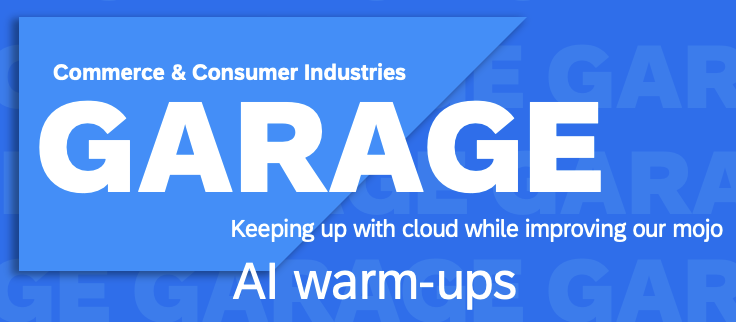

On github @ [Github Docu](https://github.tools.sap/D061192/hackathonnotebooks)

# Installing Joule on BTP in ~6 minutes

A step-by-step guide to 

- install Joule on BTP with a Mac in ~6 minutes
- use a simple Joule App via CLI and Joule's Web chat app
- dig deeper into the sample Joule App

## Necessary Prerequisites:

- install [Jupyter](https://jupyter.org/install)
- install the [Jupyter bash kernel ](https://github.com/takluyver/bash_kernel)
- create a global account in [Canary - Public Cloud Feature Set B](https://cp-control-client-uc2.cfapps.sap.hana.ondemand.com/index.html).. 
    - .. as shown in  [this 1 minute video](https://video.sap.com/media/t/1_44yjywhu)
    - It is important you choose the same options as shown in that video.
    - The name of the account should have letters and numbers only (no '-' '_' etc)
- install the [BTP CLI](http://developers.sap.com/tutorials/cp-sapcp-getstarted..html)
- install the [Joule CLI](https://help.sap.com/docs/joule/service-guide/install-and-update-command-line-interface?locale=en-US&q=Create%20Joule%20Subscription%20and%20Instance)
- Create a new Global Account at  [BTP Cockpit Canary - Public Cloud Feature Set B"](https://cp-control-client-uc2.cfapps.sap.hana.ondemand.com/index.html) with just letter/digits in the name.


## To run this journey..
- git clone https://github.tools.sap/D061192/hackathonnotebooks.git
- jupyter lab hackathonnotebooks/docs/JouleScriptsREADME.ipynb
- **select the Bash Kernel** in Jupyter
- then go through the steps below in jupyter

## Videos of this journey are here..

- [Installing Joule on BTP in 6 minutes](https://video.sap.com/media/t/1_7uf1htz4)
- [Using Joule on BTP in 5 minutes](https://video.sap.com/media/t/1_a73j5jyz)
- 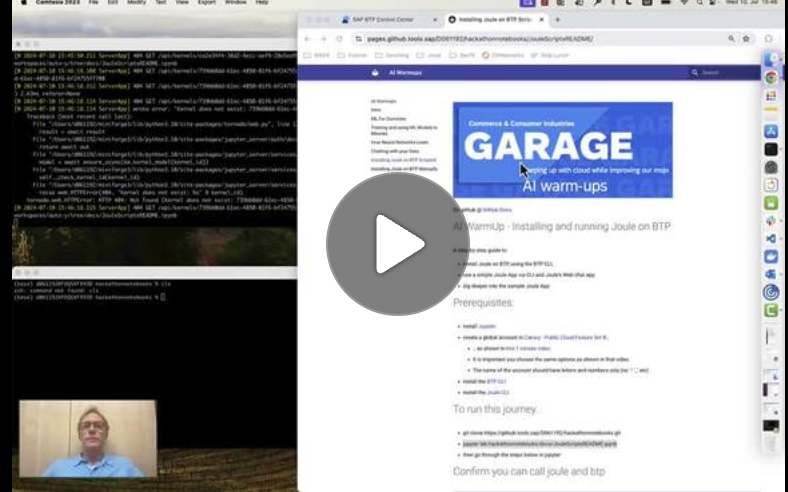


## Confirm you can call joule and btp



In [ ]:
# Both commands must execute ok to continue..
echo "If Joule CLI is installed this will run ok.."
joule -V
echo "If BTP CLI is installed, this will run ok.."
btp

## Personalize then run this code block

In [ ]:
export BTPGLOBALACCOUNT=20240715c
export BTP_MY_EMAIL=ken.lomax@sap.com

echo "BTPGLOBALACCOUNT must be the name of your new empty Global Subaccount, and BTP_MY_EMAIL must be your email. Please confirm these are correct before proceeding:"
echo "BTPGLOBALACCOUNT: $BTPGLOBALACCOUNT"
echo "BTP_MY_EMAIL: $BTP_MY_EMAIL"

## Run this script (on a Mac) to install Joule on BTP in ~5 minutes

In [ ]:
echo "=====Joule Setup: Logging out of btp"
btp logout

echo "=====Joule Setup: Logging into your global account on btp"
btp login --sso --url https://canary.cli.btp.int.sap --subdomain $BTPGLOBALACCOUNT

echo "=====Joule Setup: Getting the ID of your new globale account"
btp get accounts/global-account --global-account $BTPGLOBALACCOUNT
export BTP_GLOBAL_ACCOUNT_ID=`btp get accounts/global-account --global-account $BTPGLOBALACCOUNT | grep "global account id" | awk '{print $4;}'` 
echo "=====Joule Setup: BTP_GLOBAL_ACCOUNT_ID: " $BTP_GLOBAL_ACCOUNT_ID

echo "=====Joule Setup: Setting up a new EU10 subaccount"
btp create accounts/subaccount --region eu10-canary --subdomain EU10$BTPGLOBALACCOUNT --display-name EU10$BTPGLOBALACCOUNT

# List the new subaccount(s) and wait for the state OK
echo "=====Joule Setup: Waiting forthe subaccount to be deployed..."
until [ "`btp list accounts/subaccount | grep "EU10" | awk '{print $9;}'`" = "OK" ]
do 
	sleep 5; 
	echo -n "waiting.."
done

echo "=====Joule Setup: Getting the ID of EU10_SUBACCOUNT"
export BTP_EU10_SUBACCOUNT_ID=`btp list accounts/subaccount | grep EU10 | awk '{print $1;}'`
echo "BTP_EU10_SUBACCOUNT_ID is:" $BTP_EU10_SUBACCOUNT_ID

echo "=====Joule Setup: Enabling CLoud Foundry in EU10 subaccount"
btp create  accounts/environment-instance --subaccount $BTP_EU10_SUBACCOUNT_ID --environment cloudfoundry --service cloudfoundry --plan standard --parameters "{\"instance_name\":\"cfeu10$BTPGLOBALACCOUNT\"}"

echo "=====Joule Setup: Waiting until cloud foundry is active"
btp list accounts/environment-instance --subaccount $BTP_EU10_SUBACCOUNT_ID
until [ "`btp list accounts/environment-instance --subaccount $BTP_EU10_SUBACCOUNT_ID | grep "eu10" | awk '{print $4;}'`" = "OK" ]
do 
	sleep 5; 
	echo -n "waiting.."
done

echo "=====Joule Setup: Adding additional-tenant entitlement for the service Cloud Identity Services to our EU10 sub account"
btp assign accounts/entitlement --to-subaccount $BTP_EU10_SUBACCOUNT_ID --for-service sap-identity-services-onboarding   --plan additional-tenant --enable true
until [ "`btp list accounts/entitlement --subaccount $BTP_EU10_SUBACCOUNT_ID | grep sap-identity-services-onboarding  | awk '{print $1;}'`" = "sap-identity-services-onboarding" ]
do 
	sleep 5; 
	echo -n "waiting.."
done

echo "=====Joule Setup: Subscribing to the Cloud Identity Services additional-tenant plan"
btp subscribe accounts/subaccount --subaccount $BTP_EU10_SUBACCOUNT_ID --to-app sap-identity-services-onboarding --plan additional-tenant --parameters "{ \"cloud_service\": \"PRODUCTIVE\" }"

echo "=====Joule Setup: Waiting until we see state OK"
until [ "`btp list accounts/environment-instance --subaccount $BTP_EU10_SUBACCOUNT_ID | grep "eu10"  | awk '{print $4;}'`" = "OK" ]
do 
	sleep 5; 
	echo -n "waiting.."
done

echo "=====Joule Setup: Waiting until the status is SUBSCRIBED"
until [ "`btp get accounts/subscription --subaccount $BTP_EU10_SUBACCOUNT_ID --of-app sap-identity-services-onboarding --plan additional-tenant | grep "status"  | awk '{print $2;}'`" = "SUBSCRIBED" ]
do 
	sleep 5; 
	echo -n "waiting.."
done

echo "=====Joule Setup: Getting the Trust URL"
export BTP_TRUST_URL=`btp get accounts/subscription --subaccount $BTP_EU10_SUBACCOUNT_ID --of-app sap-identity-services-onboarding --plan additional-tenant | grep "application url"  | sed 's#https://##g' | sed 's#/admin##g' | awk '{print $3;}'` 
echo "=====Joule Setup: Trust URL: " $BTP_TRUST_URL

echo "=====Joule Setup: Creating a subaccount in EU12"
btp create accounts/subaccount --region eu12 --subdomain EU12$BTPGLOBALACCOUNT --display-name EU12$BTPGLOBALACCOUNT

echo "=====Joule Setup: Waiting for the new subaccount EU12 to be active"
btp list accounts/subaccount
until [ "`btp list accounts/subaccount | grep "EU12" | awk '{print $9;}'`" = "OK" ]
do 
	sleep 5; 
	echo -n "waiting.."
done

echo "=====Joule Setup: Getting the ID of the new EU12 Subaccount"
export BTP_EU12_SUBACCOUNT_ID=`btp list accounts/subaccount | grep EU12 | awk '{print $1;}'`
echo "=====Joule Setup: BTP_EU12_SUBACCOUNT_ID is:" $BTP_EU12_SUBACCOUNT_ID

echo "=====Joule Setup: Enabling Cloud Foundry on your EU12 subccount"
btp create  accounts/environment-instance --subaccount $BTP_EU12_SUBACCOUNT_ID --environment cloudfoundry --service cloudfoundry --plan standard --landscape cf-eu12 --parameters "{\"instance_name\":\"cfeu12$BTPGLOBALACCOUNT\"}"

echo "=====Joule Setup: Waiting until Cloud Foundry is ready"
btp list accounts/environment-instance --subaccount $BTP_EU12_SUBACCOUNT_ID
until [ "`btp list accounts/environment-instance --subaccount $BTP_EU12_SUBACCOUNT_ID | grep "eu12" | awk '{print $4;}'`" = "OK" ]
do 
	sleep 5; 
	echo -n "waiting.."
done

echo "=====Joule Setup: Adding entitlement to Joule das-service-canary"
btp assign accounts/entitlement --to-subaccount $BTP_EU12_SUBACCOUNT_ID --for-service das-service-canary --plan designer --amount 1

echo "=====Joule Setup: Adding entitlement to Joule das-application-canary"
btp assign accounts/entitlement --to-subaccount $BTP_EU12_SUBACCOUNT_ID --for-service das-application-canary --plan development --enable true 

echo "=====Joule Setup: Establishing trust with the additional-tenant on EU10"
btp create security/trust --idp $BTP_TRUST_URL --subaccount $BTP_EU12_SUBACCOUNT_ID --domain $BTP_TRUST_URL --name $BTP_TRUST_URL

echo "=====Joule Setup: Subscribing to Joule"
btp subscribe accounts/subaccount --subaccount $BTP_EU12_SUBACCOUNT_ID  --to-app das-application-canary-ias --plan development

echo "=====Joule Setup: Waiting until the status is SUBSCRIBED" 
btp list accounts/subscription --subaccount $BTP_EU12_SUBACCOUNT_ID  | grep das-application-canary-ias
until [ "`btp list accounts/subscription --subaccount $BTP_EU12_SUBACCOUNT_ID  | grep das-application-canary-ias | awk '{print $8;}'`" = "SUBSCRIBED" ]
do 
	sleep 5; 
	echo -n "waiting.."
done

echo "=====Joule Setup: Creating SAP Digital Assistant instance"
btp create services/instance --subaccount $BTP_EU12_SUBACCOUNT_ID --service das-service-canary --plan-name  designer --offering-name das-service-canary

echo "=====Joule Setup: Noting the BTP_TRUST_EU12_URL as we need it later."
export BTP_TRUST_EU12_URL=`btp list services/instance --subaccount $BTP_EU12_SUBACCOUNT_ID | grep das-service-canary | awk '{print $2;}'`
echo "=====Joule Setup: BTP_TRUST_EU12_URL" $BTP_TRUST_EU12_URL

echo "=====Joule Setup: Creating Service Binding to the SAP Digital Assistant"
btp create services/binding --subaccount $BTP_EU12_SUBACCOUNT_ID --binding mybinding --service-instance $BTP_TRUST_EU12_URL

echo "=====Joule Setup: Getting the JOULE APP URL and store in the env variable BTP_JOULE_APP"
export BTP_JOULE_APP=`btp list accounts/subscription --subaccount $BTP_EU12_SUBACCOUNT_ID| grep as-application-canary-ias | awk '{print $9;}'` 
echo "=====Joule Setup: BTP_JOULE_APP" $BTP_JOULE_APP

echo "=====Joule Setup: Extracting the environment variables we will use to run sapdas login.."
export BTP_JOULE_AUTHURL=`btp get services/binding --subaccount $BTP_EU12_SUBACCOUNT_ID --name mybinding | grep " url:" | awk '{print $2;}'`
export BTP_JOULE_CLIENTSECRET=`btp get services/binding --subaccount $BTP_EU12_SUBACCOUNT_ID --name mybinding | grep "clientsecret" | awk '{print $2;}'`
export BTP_JOULE_CLIENTID=`btp get services/binding --subaccount $BTP_EU12_SUBACCOUNT_ID --name mybinding | grep "clientid" | awk '{print $2;}'`
export BTP_XSAPPNAME=`btp get services/binding --subaccount $BTP_EU12_SUBACCOUNT_ID --name mybinding | grep " xsappname:" | awk '{print $2;}'`
export BTP_DASAPPID=`btp get services/binding --subaccount $BTP_EU12_SUBACCOUNT_ID --name mybinding | grep " xsappname:" | awk '{print $2;}'  | cut -d'|' -f2 `

echo "=====Joule Setup: BTP_JOULE_AUTHURL: " $BTP_JOULE_AUTHURL
echo "=====Joule Setup: BTP_JOULE_CLIENTSECRET: " $BTP_JOULE_CLIENTSECRET
echo "=====Joule Setup: BTP_JOULE_CLIENTID: " $BTP_JOULE_CLIENTID
echo "=====Joule Setup: BTP_XSAPPNAME: " $BTP_XSAPPNAME
echo "=====Joule Setup: BTP_DASAPPID: " $BTP_DASAPPID

echo "=====Joule Setup: Adding a role collection for ourselves with capability_release_admin and capability_developer rights.."
btp create security/role-collection joulesuperpowers --description joulesuperpowers --subaccount $BTP_EU12_SUBACCOUNT_ID
btp add security/role capability_developer --to-role-collection joulesuperpowers --of-app $BTP_XSAPPNAME --of-role-template capability_developer --subaccount $BTP_EU12_SUBACCOUNT_ID
btp add security/role capability_release_admin --to-role-collection joulesuperpowers --of-app $BTP_XSAPPNAME --of-role-template capability_release_admin --subaccount $BTP_EU12_SUBACCOUNT_ID
btp add security/role end_user --to-role-collection joulesuperpowers --of-app $BTP_DASAPPID --of-role-template end_user --subaccount $BTP_EU12_SUBACCOUNT_ID
btp assign security/role-collection joulesuperpowers --to-user $BTP_MY_EMAIL --of-idp sap.default --subaccount $BTP_EU12_SUBACCOUNT_ID

echo "=====Joule Setup: If you saw no errors, setup is complete."
echo "=====Joule Setup: You can now log into joule with.."
echo "=====Joule Setup:  Copy and paste the following command 'joule login...' into a terminal, to login into joule.."
echo "joule login --apiurl $BTP_JOULE_APP --default-idp --authurl $BTP_JOULE_AUTHURL --clientid '$BTP_JOULE_CLIENTID' --clientsecret '$BTP_JOULE_CLIENTSECRET' --username $BTP_MY_EMAIL"


## Log into Joule...
Copy and paste the "joule login ..." command printed above, into a terminal to log into joule

## Confirm you are logged into joule

In [ ]:
joule status

## Import this Destination in your BTP Subaccount

Write the destination details to a file so we can then import it into btp..


In [ ]:
cat <<EOT >> destination.txt
Name=WEATHER 
URL=https://api.weather.com/v3 
ProxyType=Internet 
Type=HTTP 
URL.queries.apiKey=c322ef22435d40bfa2ef22435df0bfbe 
Authentication=NoAuthentication 
EOT

## Import the Destination into btp

In [ ]:
# Run then follow the output instruction..
echo "Go to https://canary.cockpit.btp.int.sap/cockpit/#/globalaccount/$BTP_GLOBAL_ACCOUNT_ID/subaccount/$BTP_EU12_SUBACCOUNT_ID/destinations and import the file $(pwd)/destination.txt"

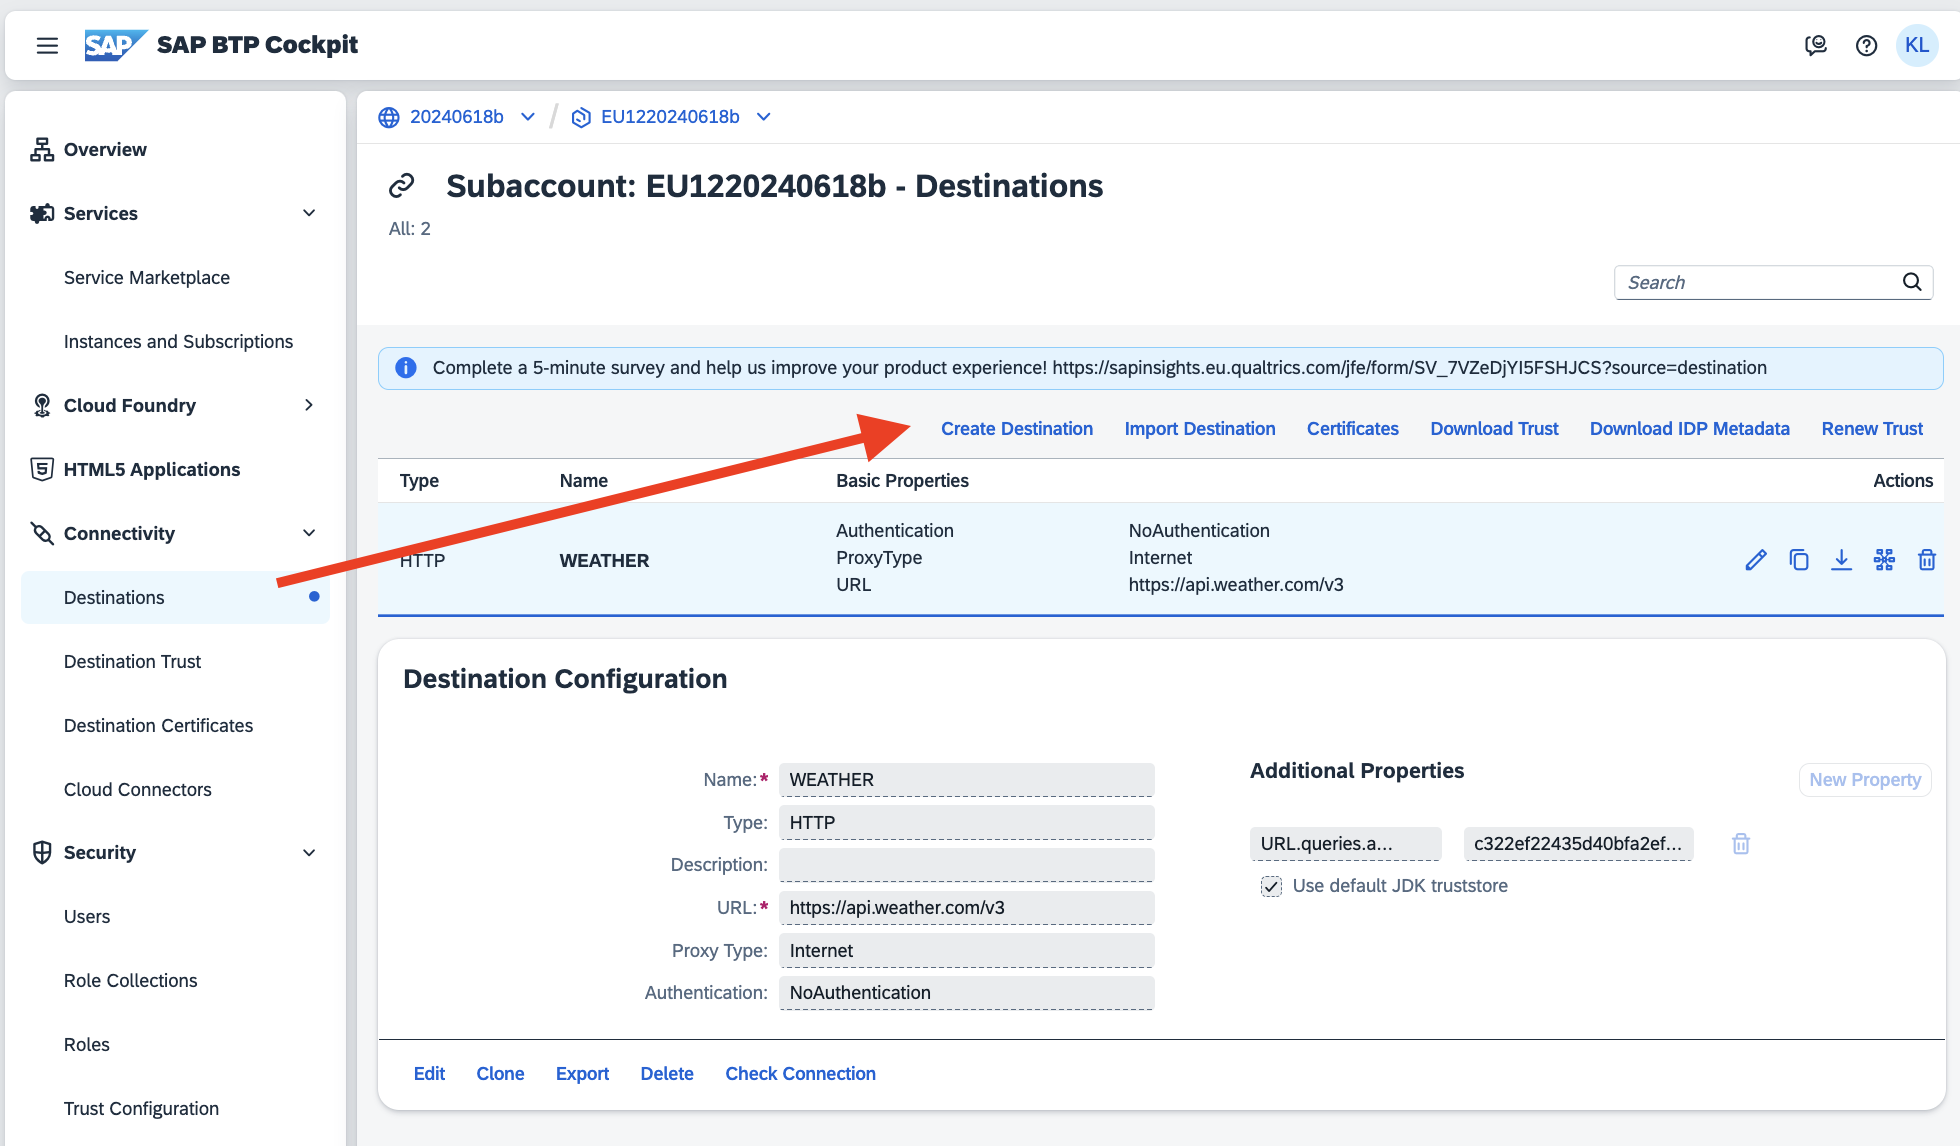

## Clone the joule demo repo


Create a token at https://github.tools.sap/settings/tokens with repo rights and export to MY_GITHUB_TOKEN:

In [ ]:
#export MY_GITHUB_TOKEN=your_github_token_with_repo_right
export MY_GITHUB_TOKEN=xxx


Clone and run the Joule demo app:

In [ ]:
echo "=====Joule Setup: cloning "
git clone https://$MY_GITHUB_TOKEN@github.tools.sap/DAS-Samples/da-mc-developers-hands-on
pushd da-mc-developers-hands-on

echo "=====Joule Setup: switching branch"
git checkout 7-Weather-Dialog-Functions
pushd my_first_assistant

echo "=====Joule Setup: Deploying Joule"
joule deploy my_first_assistant.da.sapdas.yaml --compile

echo "=====Joule Setup: Trying out Joule"
joule dialog my_first_assistant "What is the weaether like in Munich?"
joule dialog my_first_assistant "Would I need an umbrella in Paris today or would shorts be fine?"
joule dialog my_first_assistant "I love Barry Manilow"


# Launch Joule:

Run the following command and follow this path to reach your joule app..

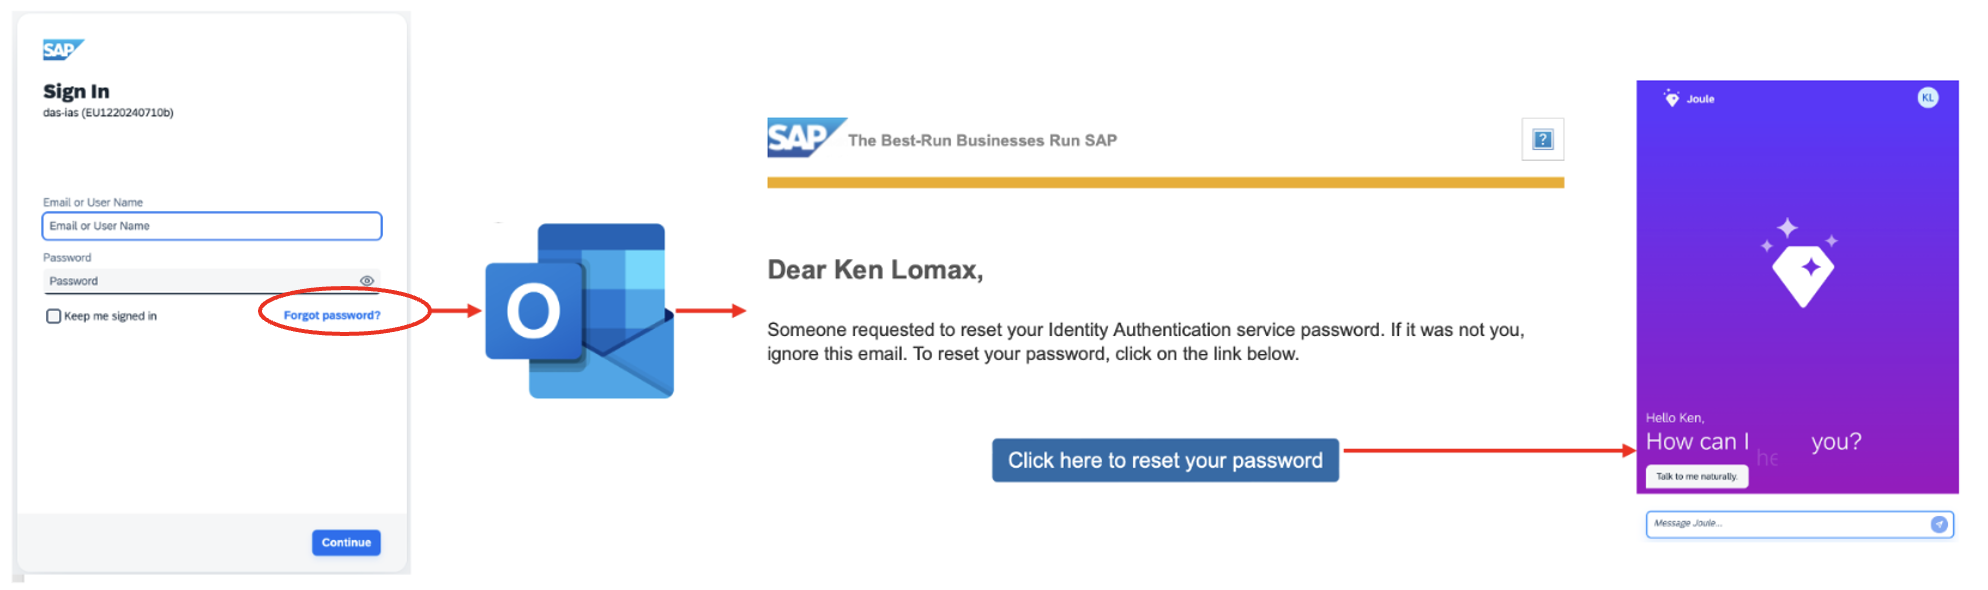

In [ ]:
joule launch my_first_assistant

## What is going on?

### From 30000 feet

This Joule code creates a chatbot that:

- answers **human-like** queries about the weather in a defined set of cities
- does not, as designed, support other general queries

For example:
- "How is the weather in Paris"
- "How's it looking in Paris today?"
- "What temperature in Paris are we talking about?" .. should all return an answer similar to "The weather in Paris is 28 degrees with a slight chance of rain"

Other queries like "What is your name" should result in "I cannot help you with your query"

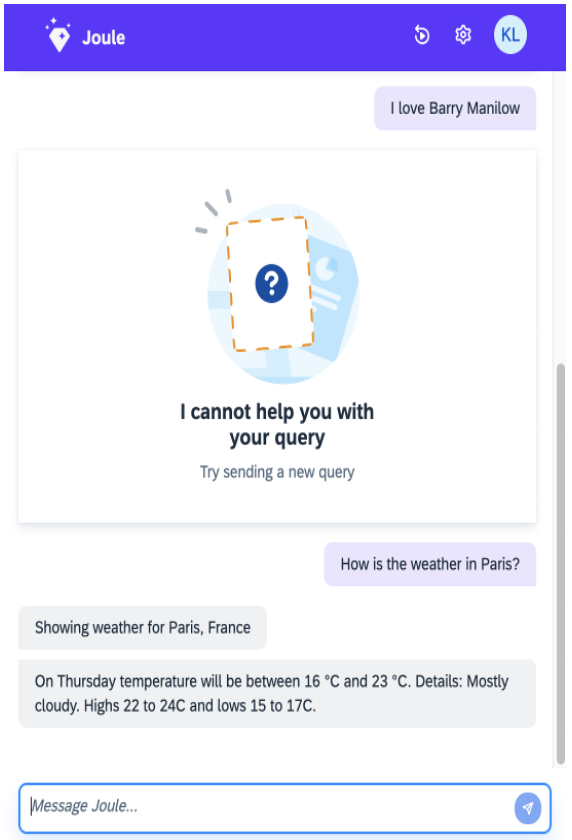

### From 20000 feet

In Joule's lingo..

- Our topic ("**Capability**") that we are choosing to support is "Weather"
- The user may express an **Intent** to enquire about the Weather. If so, Joule should recognise that intent, and act upon it.
- The **Entity** we need to extract from this **Intent** is the "city" 
- We define a **Destination** REST endpoint for retrieving the weather report for that city (api.weather.com)
- There can be more than one capability, intent, entity, destination, but we will have just one of each..
- The Joule conversation flows through **Nodes**
  - Nodes are arranged in trees, and are invoked if their **condition** is met
  - Our conversation will consist of 3 nodes:
    - a "root" node **fetch_weather** to be invoked when a weather "Intent" is recognised, which should then
      - extract the city from the intent
      - call a REST API to get the weather
      - store the answer 
    - and then either
      - a node **display_weather** to be invoked when we have a successful answer from fetch_weather node, that returns a message to the user with the weather
      - a node **display_error** to be invoked when we have a failure from fetch_weather node

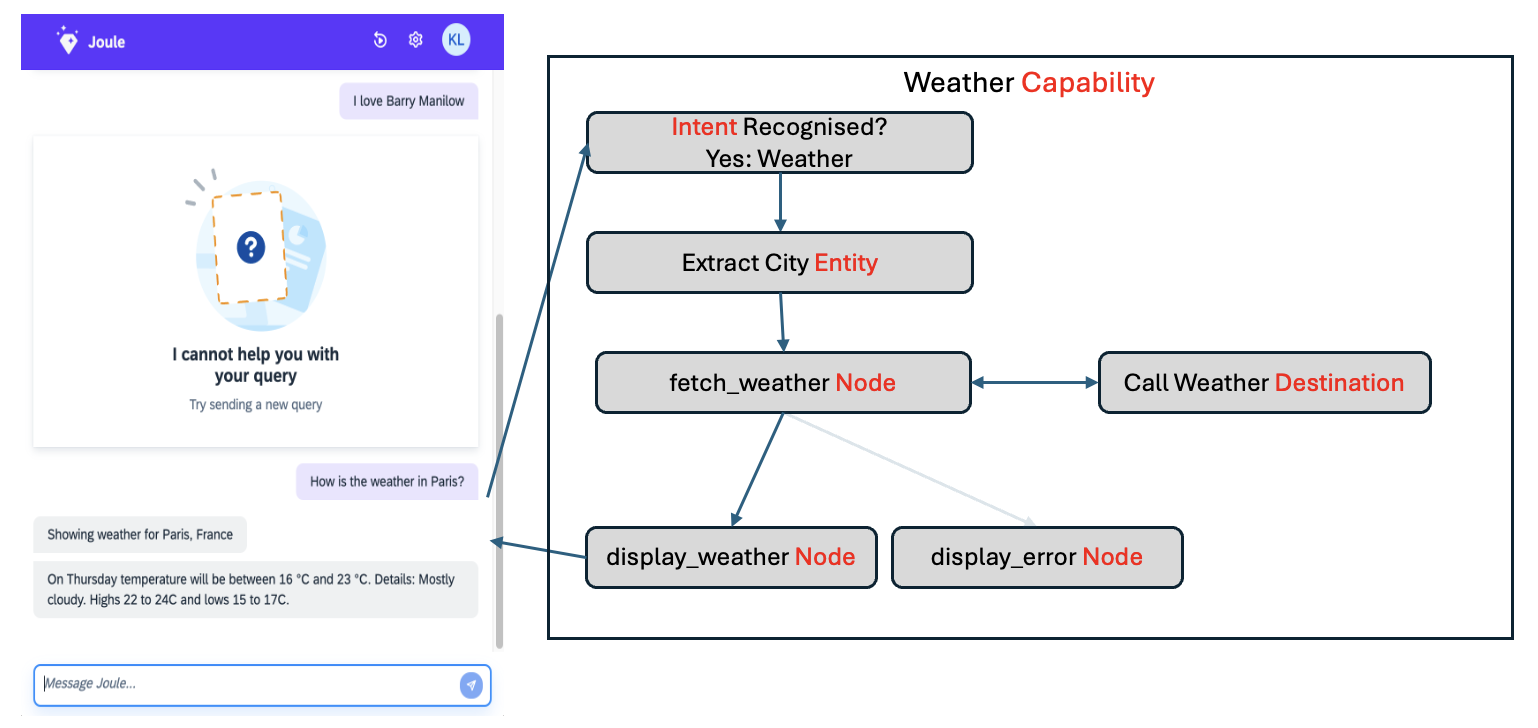

### From 1000 feet

Compare the source code with this:

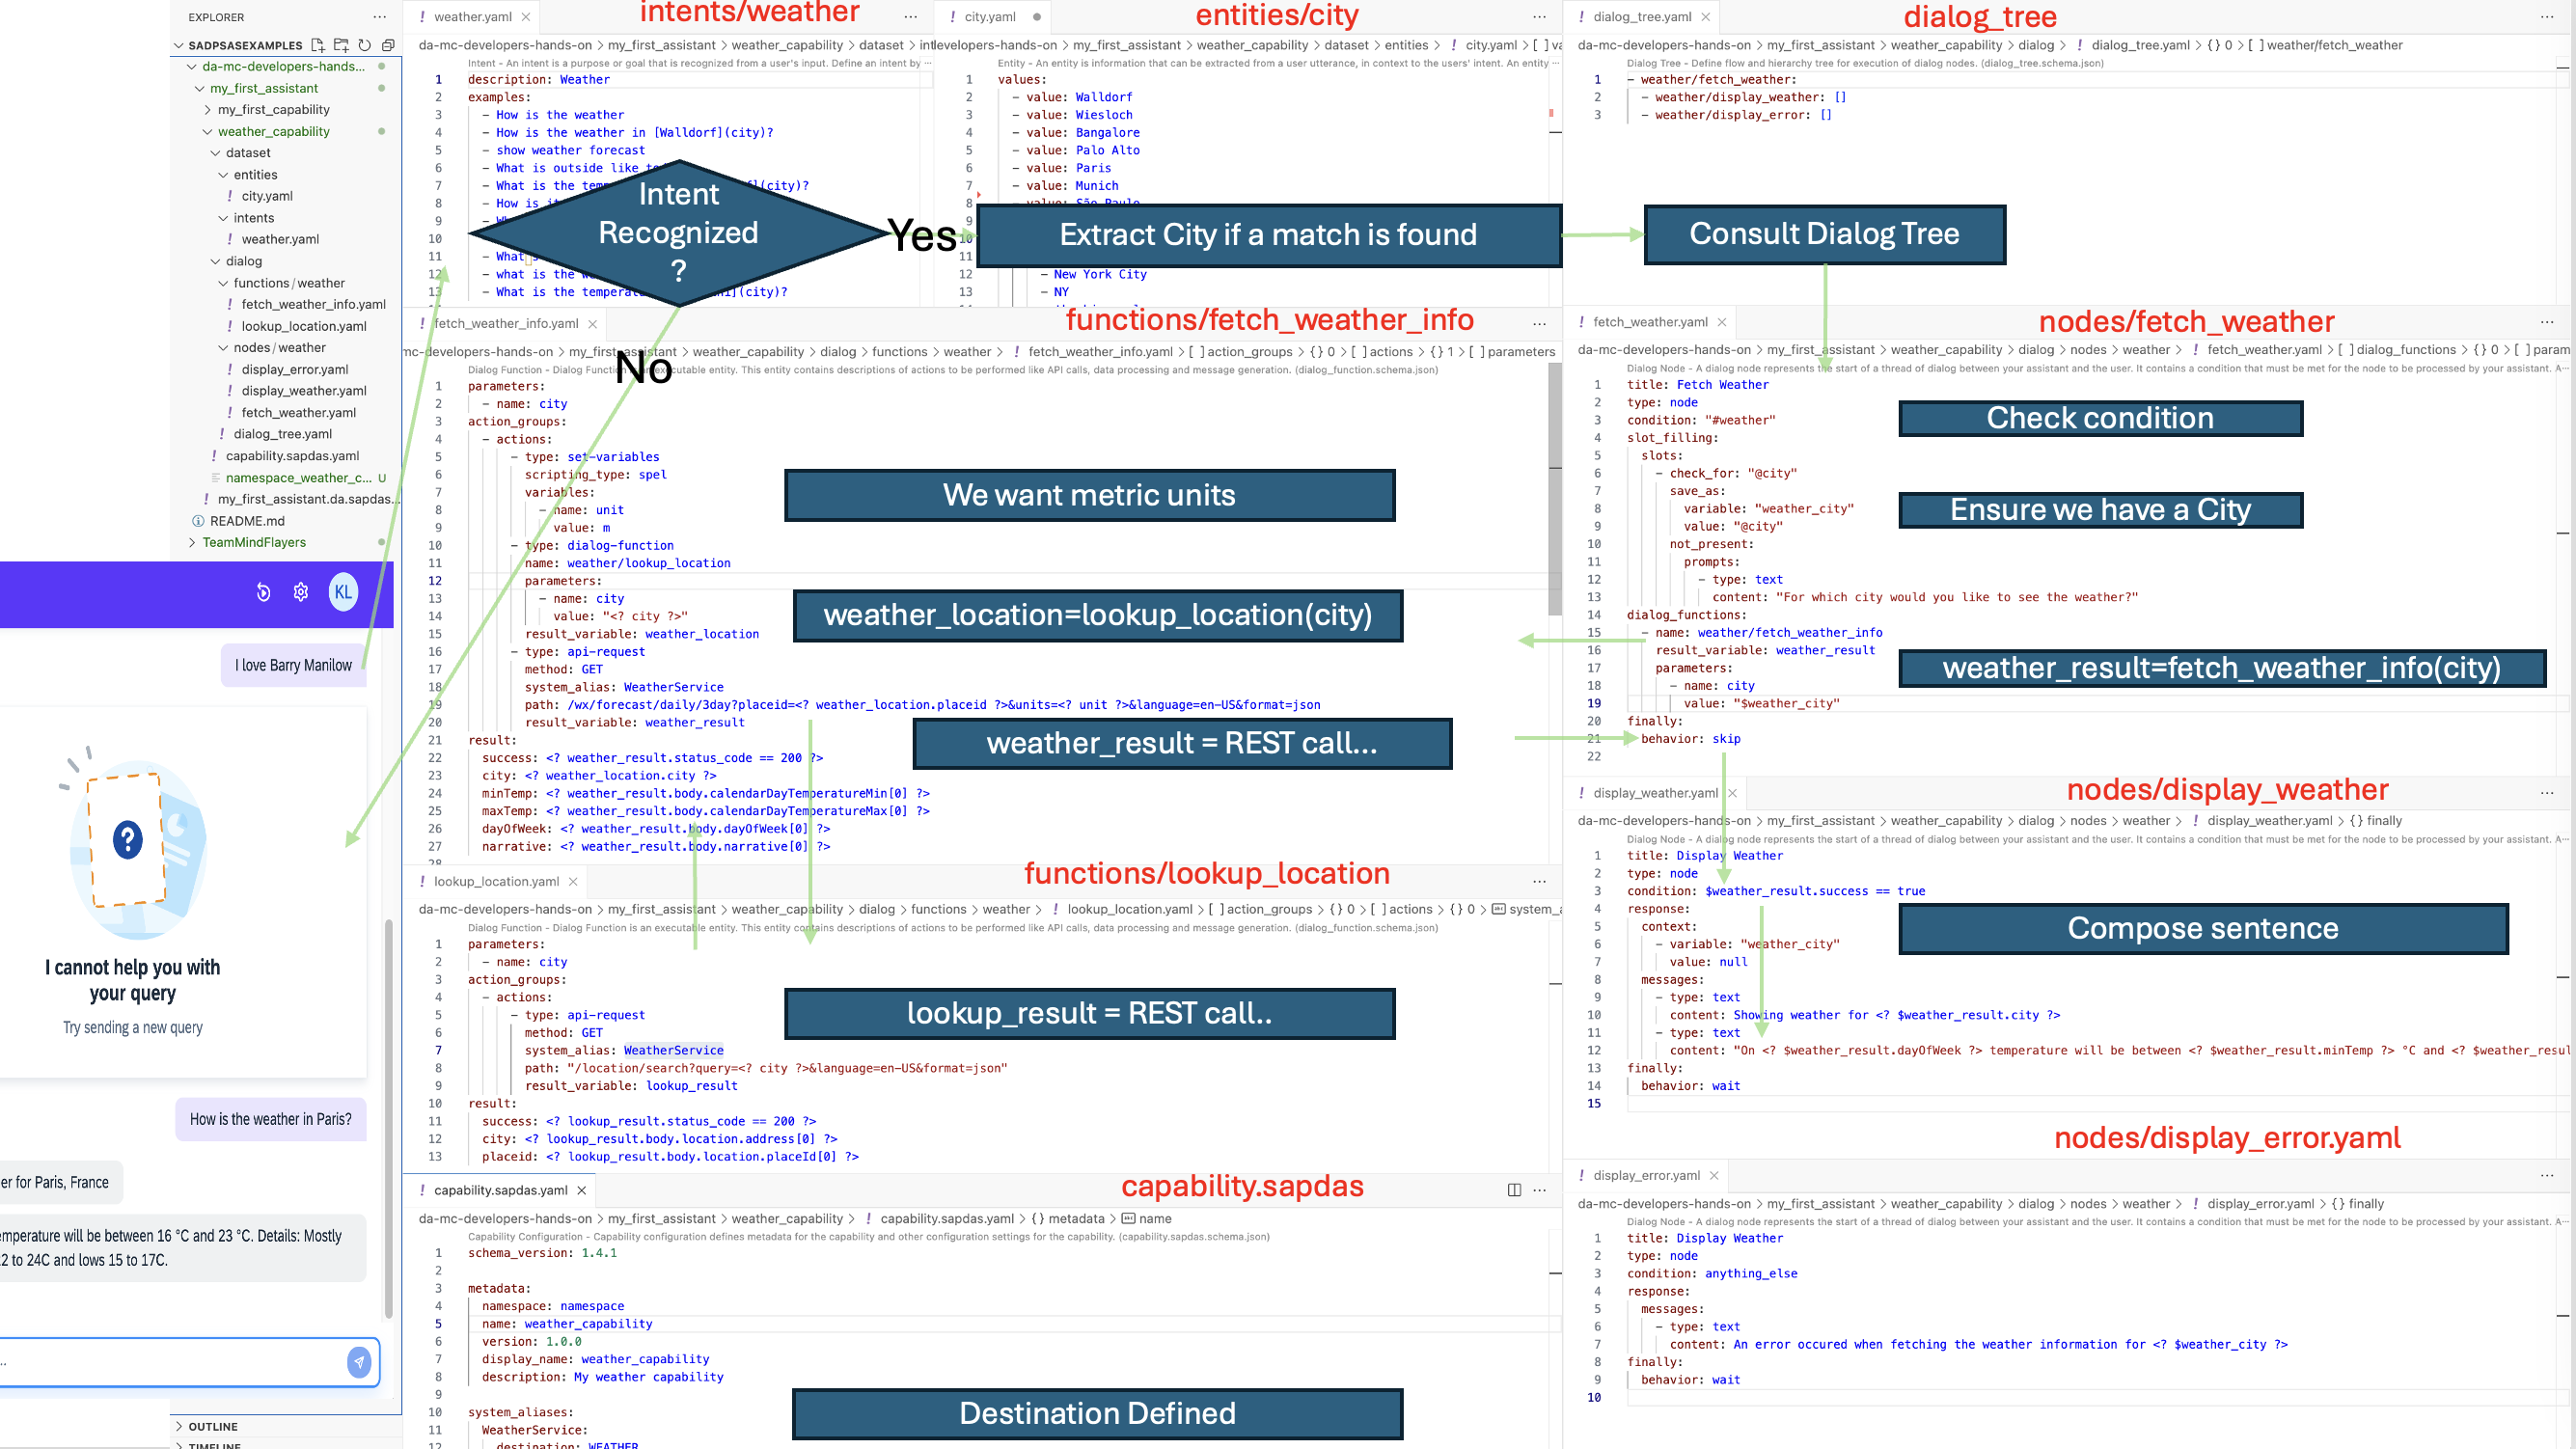

### From Ground level

Go through the source code :)


## To run in debug mode..

In our demo app we login with IAS user, so to run Joule in debug mode, we need to add capability_developer role to our IAS user (and not only default IdP user).


In [ ]:
# List the users of your custom identity provider
btp list security/user --of-idp sap.custom --subaccount $BTP_EU12_SUBACCOUNT_ID 
# We want the one xxx-xxx-xx
btp list security/user --of-idp sap.custom --subaccount $BTP_EU12_SUBACCOUNT_ID | head -2 | tail -1
export BTP_EU12_IDP_USER_ID=`btp list security/user --of-idp sap.custom --subaccount $BTP_EU12_SUBACCOUNT_ID | head -2 | tail -1`


Store the ID of this new subaccount as the env variable BTP_EU12_SUBACCOUNT_ID

In [ ]:
echo "BTP_EU12_IDP_USER_ID is:" $BTP_EU12_IDP_USER_ID
# Assign our role-collection to our IAS user 
btp assign security/role-collection joulesuperpowers --to-user $BTP_EU12_IDP_USER_ID --of-idp sap.custom --subaccount $BTP_EU12_SUBACCOUNT_ID

Relaunch Joule in cognito mode (to ignore stale cookies)

In [ ]:
joule launch my_first_assistant

You should then see a debug button in the joule client window

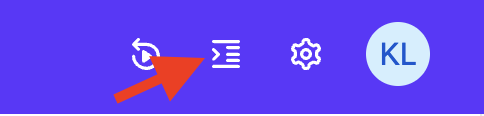


## Next steps:

- Try the Joule IDE plugin @ https://help.sap.com/docs/joule/service-guide/joule-ide-extension?locale=en-US
- Joule docu: https://wiki.one.int.sap/wiki/display/OPECFKM/Joule
- Using Joule's Web Client is described here: https://github.tools.sap/DAS/webclient


## Further examples:

- Errors during installation -> https://itsm.services.sap/sp?id=sc_category
- Study the Joule tutorial in more depth at https://github.tools.sap/DAS-Samples/da-mc-developers-hands-on
- [Video demoing how to create an initial Joules and Chuck Norris chat](https://sap.sharepoint.com/sites/102567/_layouts/15/stream.aspx?id=%2Fsites%2F102567%2FShared%20Documents%2F2%2E%20Solution%20Assets%2FJoule%2FEnablement%20tutorials%2F%5BAI%40SLF%5D%20Chocolearn%2D20231205%5F163131%2DMeeting%20Recording%2Emp4&referrer=StreamWebApp%2EWeb&referrerScenario=AddressBarCopied%2Eview%2Eae40a47e%2D97ac%2D46c7%2Dba4a%2Dcda0d3d15524) 
- [Video demoing how to add a Weather Capability by Timothy Jannsen and Nathan Droba](https://sap.sharepoint.com/:v:/r/sites/102567/Shared%20Documents/2.%20Solution%20Assets/Joule/Enablement%20tutorials/SAP%20Digital%20Assistant%20-%20Adding%20a%20Weather%20Capability.mp4?csf=1&web=1&e=Lpk1vJ) and [setup](https://workzone.one.int.sap/site#workzone-home&/groups/bj5ax8gAxEkFxGXcO8EIWK/workpage_tabs/aVDrYRMybHgAyWmmyb5mRk)
- HackAiThon PoC from Team Mind Flayers @
  - Using
    - Destination
      - URL=https\://backoffice.xxxx.model-t.myhybris.cloud/odata2webservices
      - Name=D43_COMMERCE
      - ProxyType=Internet
      - Type=HTTP
      - Authentication=BasicAuthentication
      - User=admin
  - https://wiki.one.int.sap/wiki/display/prodandtech/AI+Talk%3A+Building+a+CX+Integration+Assistant+with+Joule
  - https://wiki.one.int.sap/wiki/display/prodandtech/HackAIthon+PoC+from+Team+Mind+Flayers
- This journey was constructed by following various documents from [here](https://help.sap.com/docs/joule/service-guide/initial-set-up?


## Joules FAQ Forum:

- Questions on Joule: ask questions on stackenterprise, and add a joule tag:  https://sap.stackenterprise.co/
locale=en-US)

